In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 1
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=1
    print("Full run mode")



Quick test mode


In [3]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(300)
else:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxEStateIndex,RDKit_MinEStateIndex,RDKit_MaxAbsEStateIndex,RDKit_MinAbsEStateIndex,RDKit_qed,RDKit_MolWt,RDKit_HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,-0.536525,10.634953,0.297618,0.461644,172.180,160.084,...,1,0,1,1,0,0,0,1,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,-0.625117,12.229922,0.211872,0.322574,456.108,446.028,...,1,0,1,0,0,1,1,1,1,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,-0.193012,12.333151,0.193012,0.344216,420.472,400.312,...,0,1,1,0,1,1,1,1,1,0
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,0.416667,2.263889,0.416667,0.351522,60.172,52.108,...,0,0,0,1,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,-0.075556,8.613426,0.075556,0.609080,139.154,130.082,...,1,0,1,0,1,1,1,1,1,0


In [4]:
data_with_features['H?'] = data_with_features['MP'].apply(lambda x: 1 if x > 250 else 0)
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxEStateIndex,RDKit_MinEStateIndex,RDKit_MaxAbsEStateIndex,RDKit_MinAbsEStateIndex,RDKit_qed,RDKit_MolWt,RDKit_HeavyAtomMolWt,...,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166,H?
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,-0.536525,10.634953,0.297618,0.461644,172.180,160.084,...,0,1,1,0,0,0,1,0,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,-0.625117,12.229922,0.211872,0.322574,456.108,446.028,...,0,1,0,0,1,1,1,1,0,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,-0.193012,12.333151,0.193012,0.344216,420.472,400.312,...,1,1,0,1,1,1,1,1,0,1
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,0.416667,2.263889,0.416667,0.351522,60.172,52.108,...,0,0,1,0,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,-0.075556,8.613426,0.075556,0.609080,139.154,130.082,...,0,1,0,1,1,1,1,1,0,0


In [5]:
def feature_engineering_workflow(data_type):

    # Extract all feature columns
    all_feature_cols = data_with_features.drop(columns=['SMILES', 'MP', 'Type', 'H?'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Subset data based on data_type
    if data_type == 'L':
        data = data_with_features[data_with_features['H?'] == 0].reset_index(drop=True)
    if data_type == 'H':
        data = data_with_features[data_with_features['H?'] == 1].reset_index(drop=True)
    print(f"Processing {data_type} dataset with shape: {data.shape}")
    print()

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, scaler_path= data_prefix + f'scaler_{data_type}.pkl', fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()

    def RFE_workflow(df_X_variance, round):
        print()
        print(f'RFE feature selection: Round {round}:')
        # Reduce features by RFE
        RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
        print()

        # Plot RFE results
        hf.RFE_plot(RFE_results)

        # Pickle save the RFE_results
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = df_X_variance[RFE_results['best_features']]

        return df_X_RFE, RFE_results

    # First round of RFE
    df_X_RFE, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    # Feature binary interactions
    df_X_interaction = hf.feature_interaction(df_X_RFE)

    # Second round of RFE
    df_X_final, RFE_results_2 = RFE_workflow(df_X_interaction, 2)


    

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_RFE, RFE_results_2, df_X_final

Total number of features: 375
Processing L dataset with shape: (286, 379)

✓ Scaler saved to: ../data_curation/processed_data/scaler_L.pkl
✓ Standardization complete. Shape: (286, 375)

Original features: 375
Removed features: 36
Remaining features: 339


RFE feature selection: Round 1:


RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 289 | RMSE: 51.0636 ± 6.3495 | Removed: [RDKit_fr_HOCCN, RDKit_fr_NH2, RDKit_fr_Ndealkylation1, RDKit_fr_Nhpyrrole, RDKit_fr_SH, RDKit_fr_allylic_oxid, RDKit_fr_amide, RDKit_fr_amidine, RDKit_fr_azo, RDKit_fr_barbitur, RDKit_fr_benzene, RDKit_fr_halogen, RDKit_fr_imidazole, RDKit_fr_imide, RDKit_fr_isothiocyan, RDKit_fr_ketone_Topliss, RDKit_fr_nitro, RDKit_fr_sulfide, RDKit_fr_sulfonamd, RDKit_fr_tetrazole, RDKit_fr_thiazole, RDKit_fr_thiocyan, RDKit_fr_unbrch_alkane, RDKit_fr_urea, MACCS_8, MACCS_11, MACCS_14, MACCS_16, MACCS_17, MACCS_18, MACCS_19, MACCS_22, MACCS_23, MACCS_25, MACCS_26, MACCS_27, MACCS_28, MACCS_29, MACCS_31, MACCS_32, MACCS_33, MACCS_36, MACCS_37, MACCS_38, MACCS_39, MACCS_40, MACCS_41, MACCS_43, MACCS_44, MACCS_45]


RFE Feature Selection:  29%|██▊       | 2/7 iteration

Iteration 1/7 | Features: 239 | RMSE: 51.4225 ± 6.2687 | Removed: [RDKit_HeavyAtomCount, RDKit_fr_Al_OH, RDKit_fr_Al_OH_noTert, RDKit_fr_Ar_NH, RDKit_fr_COO, RDKit_fr_COO2, RDKit_fr_C_S, RDKit_fr_isocyan, RDKit_fr_lactone, RDKit_fr_methoxy, RDKit_fr_morpholine, RDKit_fr_nitrile, RDKit_fr_oxime, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_piperzine, RDKit_fr_priamide, RDKit_fr_pyridine, MACCS_47, MACCS_48, MACCS_49, MACCS_51, MACCS_56, MACCS_58, MACCS_59, MACCS_60, MACCS_61, MACCS_62, MACCS_63, MACCS_64, MACCS_65, MACCS_66, MACCS_67, MACCS_69, MACCS_70, MACCS_71, MACCS_73, MACCS_76, MACCS_77, MACCS_78, MACCS_79, MACCS_84, MACCS_85, MACCS_86, MACCS_88, MACCS_90, MACCS_92, MACCS_94, MACCS_97, MACCS_164, MACCS_165]


...

Iteration 4/7 | Features: 89 | RMSE: 50.0624 ± 6.4564 | Removed: [RDKit_MaxEStateIndex, RDKit_MolWt, RDKit_MinAbsPartialCharge, RDKit_FpDensityMorgan1, RDKit_BalabanJ, RDKit_Chi0v, RDKit_Chi1, RDKit_Chi1n, RDKit_Chi2v, RDKit_Chi3n, RDKit_PEOE_VSA12, RDKit_PEOE_VSA13, RDKit_PEOE_VSA6, RDKit_SMR_VSA3, RDKit_SMR_VSA7, RDKit_SMR_VSA9, RDKit_SlogP_VSA10, RDKit_SlogP_VSA3, RDKit_SlogP_VSA7, RDKit_EState_VSA1, RDKit_EState_VSA10, RDKit_EState_VSA4, RDKit_EState_VSA7, RDKit_EState_VSA8, RDKit_EState_VSA9, RDKit_VSA_EState1, RDKit_VSA_EState10, RDKit_VSA_EState2, RDKit_NumAliphaticCarbocycles, RDKit_NumRotatableBonds, RDKit_fr_Al_COO, RDKit_fr_NH0, RDKit_fr_NH1, RDKit_fr_aldehyde, RDKit_fr_aniline, RDKit_fr_furan, RDKit_fr_para_hydroxylation, MACCS_53, MACCS_91, MACCS_98, MACCS_110, MACCS_115, MACCS_120, MACCS_138, MACCS_144, MACCS_149, MACCS_150, MACCS_153, MACCS_156, MACCS_161]


RFE Feature Selection:  86%|████████▌ | 6/7 iteration

Iteration 5/7 | Features: 39 | RMSE: 50.7373 ± 5.7552 | Removed: [RDKit_MinEStateIndex, RDKit_MinAbsEStateIndex, RDKit_qed, RDKit_HeavyAtomMolWt, RDKit_ExactMolWt, RDKit_NumValenceElectrons, RDKit_MaxPartialCharge, RDKit_MinPartialCharge, RDKit_FpDensityMorgan2, RDKit_FpDensityMorgan3, RDKit_BCUT2D_MWHI, RDKit_BCUT2D_MWLOW, RDKit_BCUT2D_CHGHI, RDKit_BCUT2D_CHGLO, RDKit_BCUT2D_LOGPHI, RDKit_BCUT2D_MRHI, RDKit_BCUT2D_MRLOW, RDKit_Chi1v, RDKit_HallKierAlpha, RDKit_Kappa2, RDKit_Kappa3, RDKit_LabuteASA, RDKit_PEOE_VSA10, RDKit_PEOE_VSA11, RDKit_PEOE_VSA2, RDKit_PEOE_VSA3, RDKit_PEOE_VSA5, RDKit_PEOE_VSA7, RDKit_SMR_VSA1, RDKit_SMR_VSA4, RDKit_SlogP_VSA4, RDKit_EState_VSA2, RDKit_EState_VSA3, RDKit_EState_VSA5, RDKit_EState_VSA6, RDKit_VSA_EState3, RDKit_VSA_EState5, RDKit_VSA_EState6, RDKit_VSA_EState7, RDKit_NumHeteroatoms, RDKit_MolLogP, RDKit_fr_Ar_OH, RDKit_fr_ether, RDKit_fr_ketone, MACCS_20, MACCS_80, MACCS_81, MACCS_96, MACCS_111, MACCS_137]


RFE Feature Selection: 100%|██████████| 7/7 iteration

Iteration 6/7 | Features: 20 | RMSE: 49.2313 ± 7.6107 | Removed: [RDKit_Chi0, RDKit_Chi2n, RDKit_Chi3v, RDKit_Chi4n, RDKit_PEOE_VSA9, RDKit_SMR_VSA5, RDKit_SMR_VSA6, RDKit_SlogP_VSA5, RDKit_VSA_EState4, RDKit_VSA_EState9, RDKit_FractionCSP3, RDKit_fr_aryl_methyl, RDKit_fr_bicyclic, RDKit_fr_ester, RDKit_fr_hdrzone, MACCS_50, MACCS_74, MACCS_121, MACCS_160]

✓ RFE Feature Selection Complete
  Best number of features: 20
  Best RMSE: 49.2313
  Best features: ['RDKit_BertzCT', 'RDKit_Chi0n', 'RDKit_Chi4v', 'RDKit_PEOE_VSA14', 'RDKit_SMR_VSA10']...



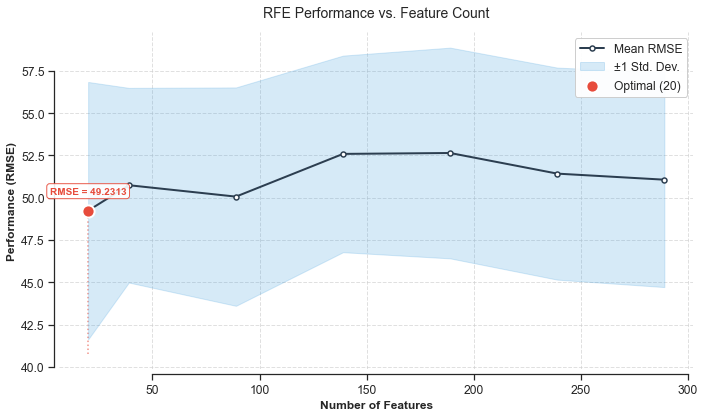

  Optimal Feature Set: 20 features
  Best RMSE: 49.2313
Generating 190 interaction features from 20 original features...

RFE feature selection: Round 2:


RFE Feature Selection:  25%|██▌       | 1/4 iteration

Iteration 0/4 | Features: 160 | RMSE: 52.7789 ± 9.5864 | Removed: [RDKit_NumHDonors, MACCS_34, MACCS_119, MACCS_126, MACCS_127, MACCS_155, RDKit_BertzCT X MACCS_119, RDKit_Chi4v X MACCS_119, RDKit_PEOE_VSA14 X RDKit_NumHDonors, RDKit_PEOE_VSA14 X MACCS_34, RDKit_PEOE_VSA14 X MACCS_119, RDKit_PEOE_VSA14 X MACCS_126, RDKit_SlogP_VSA1 X RDKit_NumHDonors, RDKit_SlogP_VSA1 X RDKit_fr_sulfone, RDKit_TPSA X RDKit_NumHDonors, RDKit_VSA_EState8 X RDKit_NumHDonors, RDKit_NHOHCount X RDKit_NumAliphaticHeterocycles, RDKit_NHOHCount X MACCS_34, RDKit_NHOHCount X MACCS_104, RDKit_NHOHCount X MACCS_127, RDKit_NHOHCount X MACCS_145, RDKit_NumAliphaticHeterocycles X RDKit_NumHDonors, RDKit_NumAliphaticHeterocycles X RDKit_fr_sulfone, RDKit_NumAliphaticHeterocycles X MACCS_34, RDKit_NumAliphaticHeterocycles X MACCS_104, RDKit_NumAliphaticHeterocycles X MACCS_119, RDKit_NumAliphaticHeterocycles X MACCS_145, RDKit_NumAliphaticHeterocycles X MACCS_155, RDKit_NumHDonors X RDKit_fr_sulfone, RDKit_NumHDonors 

RFE Feature Selection:  50%|█████     | 2/4 iteration

Iteration 1/4 | Features: 110 | RMSE: 53.0768 ± 9.2243 | Removed: [RDKit_Chi0n, RDKit_Chi4v, RDKit_NumAliphaticHeterocycles, MACCS_104, RDKit_BertzCT X RDKit_fr_sulfone, RDKit_BertzCT X MACCS_104, RDKit_BertzCT X MACCS_155, RDKit_Chi0n X RDKit_NumAliphaticHeterocycles, RDKit_Chi0n X MACCS_126, RDKit_Chi0n X MACCS_145, RDKit_Chi4v X RDKit_SlogP_VSA1, RDKit_Chi4v X RDKit_fr_sulfone, RDKit_Chi4v X MACCS_34, RDKit_Chi4v X MACCS_127, RDKit_Chi4v X MACCS_155, RDKit_PEOE_VSA14 X RDKit_SMR_VSA10, RDKit_PEOE_VSA14 X RDKit_TPSA, RDKit_PEOE_VSA14 X RDKit_NHOHCount, RDKit_PEOE_VSA14 X RDKit_NumAliphaticHeterocycles, RDKit_PEOE_VSA14 X RDKit_fr_sulfone, RDKit_PEOE_VSA14 X MACCS_104, RDKit_PEOE_VSA14 X MACCS_127, RDKit_PEOE_VSA14 X MACCS_145, RDKit_SMR_VSA10 X RDKit_SlogP_VSA1, RDKit_SMR_VSA10 X RDKit_TPSA, RDKit_SMR_VSA10 X MACCS_104, RDKit_SlogP_VSA1 X RDKit_MolMR, RDKit_SlogP_VSA1 X MACCS_126, RDKit_SlogP_VSA1 X MACCS_145, RDKit_TPSA X RDKit_VSA_EState8, RDKit_VSA_EState8 X RDKit_NHOHCount, RDKit

RFE Feature Selection:  75%|███████▌  | 3/4 iteration

Iteration 2/4 | Features: 60 | RMSE: 51.9568 ± 6.9025 | Removed: [RDKit_PEOE_VSA14, RDKit_SlogP_VSA1, RDKit_VSA_EState8, RDKit_fr_sulfone, RDKit_BertzCT X RDKit_Chi0n, RDKit_BertzCT X RDKit_Chi4v, RDKit_BertzCT X RDKit_PEOE_VSA14, RDKit_BertzCT X RDKit_VSA_EState8, RDKit_BertzCT X RDKit_MolMR, RDKit_BertzCT X MACCS_34, RDKit_BertzCT X MACCS_126, RDKit_Chi0n X RDKit_PEOE_VSA14, RDKit_Chi0n X RDKit_SMR_VSA10, RDKit_Chi0n X RDKit_TPSA, RDKit_Chi0n X RDKit_MolMR, RDKit_Chi0n X MACCS_104, RDKit_Chi0n X MACCS_119, RDKit_Chi0n X MACCS_127, RDKit_Chi0n X MACCS_155, RDKit_Chi4v X RDKit_PEOE_VSA14, RDKit_Chi4v X RDKit_SMR_VSA10, RDKit_Chi4v X RDKit_VSA_EState8, RDKit_Chi4v X RDKit_NumAliphaticHeterocycles, RDKit_Chi4v X RDKit_NumHDonors, RDKit_Chi4v X MACCS_104, RDKit_Chi4v X MACCS_145, RDKit_PEOE_VSA14 X RDKit_SlogP_VSA1, RDKit_PEOE_VSA14 X RDKit_VSA_EState8, RDKit_SMR_VSA10 X RDKit_VSA_EState8, RDKit_SMR_VSA10 X MACCS_34, RDKit_SMR_VSA10 X MACCS_126, RDKit_SMR_VSA10 X MACCS_145, RDKit_SlogP_VS

RFE Feature Selection: 100%|██████████| 4/4 iteration

Iteration 3/4 | Features: 20 | RMSE: 53.1620 ± 11.1556 | Removed: [RDKit_SMR_VSA10, RDKit_TPSA, RDKit_MolMR, RDKit_BertzCT X RDKit_SMR_VSA10, RDKit_BertzCT X RDKit_SlogP_VSA1, RDKit_BertzCT X RDKit_TPSA, RDKit_BertzCT X RDKit_NHOHCount, RDKit_BertzCT X MACCS_127, RDKit_BertzCT X MACCS_145, RDKit_Chi0n X RDKit_Chi4v, RDKit_Chi0n X RDKit_SlogP_VSA1, RDKit_Chi0n X RDKit_VSA_EState8, RDKit_Chi0n X RDKit_NHOHCount, RDKit_Chi0n X RDKit_NumHDonors, RDKit_Chi0n X RDKit_fr_sulfone, RDKit_Chi4v X RDKit_NHOHCount, RDKit_Chi4v X RDKit_MolMR, RDKit_PEOE_VSA14 X RDKit_MolMR, RDKit_SMR_VSA10 X RDKit_NHOHCount, RDKit_SMR_VSA10 X RDKit_NumAliphaticHeterocycles, RDKit_SMR_VSA10 X RDKit_NumHDonors, RDKit_SMR_VSA10 X RDKit_MolMR, RDKit_SMR_VSA10 X RDKit_fr_sulfone, RDKit_SMR_VSA10 X MACCS_119, RDKit_SMR_VSA10 X MACCS_127, RDKit_SMR_VSA10 X MACCS_155, RDKit_SlogP_VSA1 X MACCS_119, RDKit_SlogP_VSA1 X MACCS_127, RDKit_SlogP_VSA1 X MACCS_155, RDKit_TPSA X MACCS_34, RDKit_TPSA X MACCS_104, RDKit_TPSA X MACCS_1

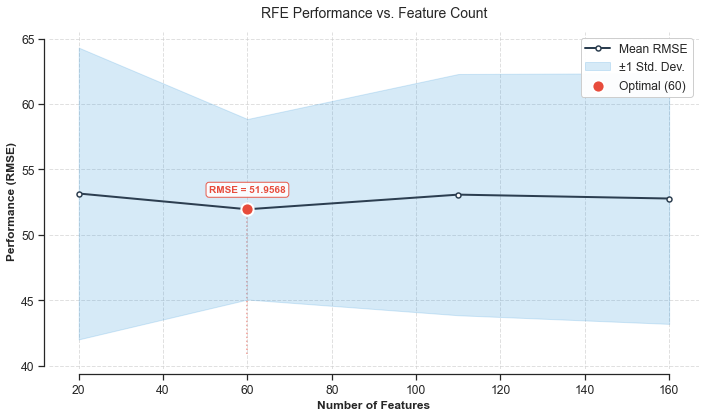

  Optimal Feature Set: 60 features
  Best RMSE: 51.9568


In [6]:
df_L_X_scaled, df_L_X_variance, RFE_results_L_1, df_L_X_RFE, RFE_results_L_2, df_L_X_final = feature_engineering_workflow('L')

Total number of features: 375
Processing H dataset with shape: (14, 379)

✓ Scaler saved to: ../data_curation/processed_data/scaler_H.pkl
✓ Standardization complete. Shape: (14, 375)

Original features: 375
Removed features: 115
Remaining features: 260


RFE feature selection: Round 1:


RFE Feature Selection:  20%|██        | 1/5 iteration

Iteration 0/5 | Features: 210 | RMSE: 28.9517 ± 10.5391 | Removed: [RDKit_fr_NH2, RDKit_fr_alkyl_halide, RDKit_fr_allylic_oxid, RDKit_fr_amide, RDKit_fr_amidine, RDKit_fr_aniline, RDKit_fr_aryl_methyl, RDKit_fr_azo, RDKit_fr_benzene, RDKit_fr_bicyclic, RDKit_fr_furan, RDKit_fr_guanido, RDKit_fr_halogen, RDKit_fr_hdrzine, RDKit_fr_hdrzone, RDKit_fr_ketone, RDKit_fr_nitrile, RDKit_fr_nitro, MACCS_37, MACCS_38, MACCS_41, MACCS_42, MACCS_43, MACCS_45, MACCS_46, MACCS_47, MACCS_49, MACCS_50, MACCS_52, MACCS_54, MACCS_56, MACCS_57, MACCS_62, MACCS_63, MACCS_65, MACCS_69, MACCS_70, MACCS_71, MACCS_72, MACCS_75, MACCS_76, MACCS_77, MACCS_78, MACCS_79, MACCS_80, MACCS_81, MACCS_82, MACCS_83, MACCS_84, MACCS_85]


RFE Feature Selection:  40%|████      | 2/5 iteration

Iteration 1/5 | Features: 160 | RMSE: 28.9435 ± 10.5389 | Removed: [RDKit_NumAromaticCarbocycles, RDKit_NumAromaticRings, RDKit_NumHAcceptors, RDKit_NumHDonors, RDKit_NumHeteroatoms, RDKit_NumRotatableBonds, RDKit_NumSaturatedHeterocycles, RDKit_NumSaturatedRings, RDKit_RingCount, RDKit_MolLogP, RDKit_MolMR, RDKit_fr_Al_COO, RDKit_fr_ArN, RDKit_fr_Ar_COO, RDKit_fr_Ar_N, RDKit_fr_Ar_NH, RDKit_fr_Ar_OH, RDKit_fr_COO, RDKit_fr_COO2, RDKit_fr_C_O, RDKit_fr_C_O_noCOO, RDKit_fr_Imine, RDKit_fr_NH0, RDKit_fr_NH1, RDKit_fr_Nhpyrrole, RDKit_fr_para_hydroxylation, RDKit_fr_phenol, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_priamide, RDKit_fr_pyridine, RDKit_fr_thiazole, RDKit_fr_urea, MACCS_17, MACCS_21, MACCS_24, MACCS_25, MACCS_36, MACCS_87, MACCS_88, MACCS_89, MACCS_90, MACCS_91, MACCS_92, MACCS_93, MACCS_94, MACCS_95, MACCS_96, MACCS_97, MACCS_98, MACCS_99]


...

Iteration 2/5 | Features: 110 | RMSE: 28.8328 ± 10.5723 | Removed: [RDKit_EState_VSA1, RDKit_EState_VSA10, RDKit_EState_VSA3, RDKit_EState_VSA5, RDKit_EState_VSA7, RDKit_EState_VSA8, RDKit_EState_VSA9, RDKit_VSA_EState1, RDKit_VSA_EState10, RDKit_VSA_EState2, RDKit_VSA_EState4, RDKit_VSA_EState5, RDKit_VSA_EState6, RDKit_VSA_EState8, RDKit_VSA_EState9, RDKit_HeavyAtomCount, RDKit_NHOHCount, RDKit_NOCount, RDKit_NumAliphaticHeterocycles, RDKit_NumAliphaticRings, RDKit_NumAromaticHeterocycles, MACCS_100, MACCS_101, MACCS_102, MACCS_103, MACCS_104, MACCS_105, MACCS_106, MACCS_107, MACCS_110, MACCS_111, MACCS_112, MACCS_113, MACCS_115, MACCS_116, MACCS_117, MACCS_118, MACCS_119, MACCS_145, MACCS_146, MACCS_147, MACCS_148, MACCS_149, MACCS_150, MACCS_151, MACCS_153, MACCS_154, MACCS_155, MACCS_156, MACCS_161]


RFE Feature Selection:  80%|████████  | 4/5 iteration

Iteration 3/5 | Features: 60 | RMSE: 27.2292 ± 11.9092 | Removed: [RDKit_MolWt, RDKit_Chi0v, RDKit_PEOE_VSA13, RDKit_PEOE_VSA14, RDKit_PEOE_VSA2, RDKit_PEOE_VSA4, RDKit_PEOE_VSA6, RDKit_PEOE_VSA7, RDKit_SMR_VSA1, RDKit_SMR_VSA10, RDKit_SMR_VSA2, RDKit_SMR_VSA3, RDKit_SMR_VSA4, RDKit_SMR_VSA5, RDKit_SMR_VSA6, RDKit_SMR_VSA9, RDKit_SlogP_VSA1, RDKit_SlogP_VSA10, RDKit_SlogP_VSA11, RDKit_SlogP_VSA12, RDKit_SlogP_VSA3, RDKit_SlogP_VSA6, RDKit_SlogP_VSA7, RDKit_SlogP_VSA8, RDKit_TPSA, MACCS_120, MACCS_121, MACCS_122, MACCS_123, MACCS_124, MACCS_125, MACCS_127, MACCS_130, MACCS_131, MACCS_133, MACCS_134, MACCS_135, MACCS_136, MACCS_137, MACCS_138, MACCS_139, MACCS_140, MACCS_142, MACCS_143, MACCS_144, MACCS_157, MACCS_158, MACCS_159, MACCS_160, MACCS_163]


RFE Feature Selection: 100%|██████████| 5/5 iteration

Iteration 4/5 | Features: 20 | RMSE: 24.5816 ± 12.2960 | Removed: [RDKit_MaxAbsEStateIndex, RDKit_HeavyAtomMolWt, RDKit_ExactMolWt, RDKit_NumValenceElectrons, RDKit_MaxAbsPartialCharge, RDKit_MinAbsPartialCharge, RDKit_FpDensityMorgan1, RDKit_FpDensityMorgan2, RDKit_FpDensityMorgan3, RDKit_BCUT2D_MWLOW, RDKit_BCUT2D_CHGHI, RDKit_BCUT2D_CHGLO, RDKit_BCUT2D_LOGPHI, RDKit_BCUT2D_LOGPLOW, RDKit_BCUT2D_MRLOW, RDKit_BalabanJ, RDKit_BertzCT, RDKit_Chi0, RDKit_Chi0n, RDKit_Chi1, RDKit_Chi1n, RDKit_Chi1v, RDKit_Chi2n, RDKit_Chi2v, RDKit_Chi3n, RDKit_Chi3v, RDKit_Chi4n, RDKit_Chi4v, RDKit_HallKierAlpha, RDKit_Ipc, RDKit_Kappa1, RDKit_Kappa2, RDKit_LabuteASA, RDKit_PEOE_VSA10, RDKit_PEOE_VSA11, RDKit_PEOE_VSA12, RDKit_PEOE_VSA8, RDKit_SMR_VSA7, RDKit_SlogP_VSA5, RDKit_EState_VSA6]

✓ RFE Feature Selection Complete
  Best number of features: 20
  Best RMSE: 24.5816
  Best features: ['RDKit_MaxEStateIndex', 'RDKit_MinEStateIndex', 'RDKit_MinAbsEStateIndex', 'RDKit_qed', 'RDKit_MaxPartialCharge']...

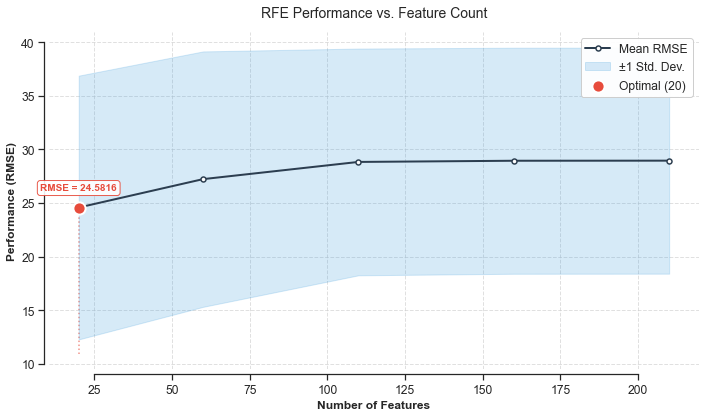

  Optimal Feature Set: 20 features
  Best RMSE: 24.5816
Generating 190 interaction features from 20 original features...

RFE feature selection: Round 2:


RFE Feature Selection:  25%|██▌       | 1/4 iteration

Iteration 0/4 | Features: 160 | RMSE: 21.1160 ± 11.7586 | Removed: [RDKit_MaxPartialCharge X RDKit_SlogP_VSA2, RDKit_MaxPartialCharge X RDKit_SlogP_VSA4, RDKit_MaxPartialCharge X RDKit_EState_VSA2, RDKit_MaxPartialCharge X RDKit_EState_VSA4, RDKit_MaxPartialCharge X RDKit_VSA_EState3, RDKit_MaxPartialCharge X RDKit_VSA_EState7, RDKit_MaxPartialCharge X RDKit_FractionCSP3, RDKit_MaxPartialCharge X MACCS_152, RDKit_MinPartialCharge X RDKit_BCUT2D_MWHI, RDKit_MinPartialCharge X RDKit_BCUT2D_MRHI, RDKit_MinPartialCharge X RDKit_Kappa3, RDKit_MinPartialCharge X RDKit_PEOE_VSA1, RDKit_MinPartialCharge X RDKit_PEOE_VSA3, RDKit_MinPartialCharge X RDKit_PEOE_VSA9, RDKit_MinPartialCharge X RDKit_SlogP_VSA2, RDKit_MinPartialCharge X RDKit_SlogP_VSA4, RDKit_MinPartialCharge X RDKit_EState_VSA2, RDKit_MinPartialCharge X RDKit_EState_VSA4, RDKit_MinPartialCharge X RDKit_VSA_EState3, RDKit_MinPartialCharge X RDKit_VSA_EState7, RDKit_MinPartialCharge X RDKit_FractionCSP3, RDKit_MinPartialCharge X MACC

RFE Feature Selection:  50%|█████     | 2/4 iteration

Iteration 1/4 | Features: 110 | RMSE: 20.1085 ± 12.4601 | Removed: [RDKit_MinAbsEStateIndex X RDKit_VSA_EState7, RDKit_MinAbsEStateIndex X RDKit_FractionCSP3, RDKit_MinAbsEStateIndex X MACCS_152, RDKit_qed X RDKit_MaxPartialCharge, RDKit_qed X RDKit_MinPartialCharge, RDKit_qed X RDKit_BCUT2D_MWHI, RDKit_qed X RDKit_BCUT2D_MRHI, RDKit_qed X RDKit_Kappa3, RDKit_qed X RDKit_PEOE_VSA1, RDKit_qed X RDKit_PEOE_VSA3, RDKit_qed X RDKit_PEOE_VSA9, RDKit_qed X RDKit_SlogP_VSA2, RDKit_qed X RDKit_SlogP_VSA4, RDKit_qed X RDKit_EState_VSA2, RDKit_qed X RDKit_EState_VSA4, RDKit_qed X RDKit_VSA_EState3, RDKit_qed X RDKit_VSA_EState7, RDKit_qed X RDKit_FractionCSP3, RDKit_qed X MACCS_152, RDKit_MaxPartialCharge X RDKit_MinPartialCharge, RDKit_MaxPartialCharge X RDKit_BCUT2D_MWHI, RDKit_MaxPartialCharge X RDKit_BCUT2D_MRHI, RDKit_MaxPartialCharge X RDKit_Kappa3, RDKit_MaxPartialCharge X RDKit_PEOE_VSA1, RDKit_MaxPartialCharge X RDKit_PEOE_VSA3, RDKit_Kappa3 X RDKit_PEOE_VSA3, RDKit_Kappa3 X RDKit_PEOE_

RFE Feature Selection:  75%|███████▌  | 3/4 iteration

Iteration 2/4 | Features: 60 | RMSE: 17.9928 ± 13.0063 | Removed: [RDKit_VSA_EState3, RDKit_VSA_EState7, RDKit_FractionCSP3, MACCS_152, RDKit_MinEStateIndex X RDKit_MinPartialCharge, RDKit_MinEStateIndex X RDKit_Kappa3, RDKit_MinEStateIndex X RDKit_PEOE_VSA1, RDKit_MinEStateIndex X RDKit_PEOE_VSA3, RDKit_MinEStateIndex X RDKit_PEOE_VSA9, RDKit_MinEStateIndex X RDKit_SlogP_VSA2, RDKit_MinEStateIndex X RDKit_SlogP_VSA4, RDKit_MinEStateIndex X RDKit_EState_VSA2, RDKit_MinEStateIndex X RDKit_EState_VSA4, RDKit_MinEStateIndex X RDKit_VSA_EState3, RDKit_MinEStateIndex X RDKit_VSA_EState7, RDKit_MinEStateIndex X RDKit_FractionCSP3, RDKit_MinEStateIndex X MACCS_152, RDKit_MinAbsEStateIndex X RDKit_qed, RDKit_MinAbsEStateIndex X RDKit_MaxPartialCharge, RDKit_MinAbsEStateIndex X RDKit_MinPartialCharge, RDKit_MinAbsEStateIndex X RDKit_BCUT2D_MWHI, RDKit_MinAbsEStateIndex X RDKit_Kappa3, RDKit_MinAbsEStateIndex X RDKit_PEOE_VSA1, RDKit_MinAbsEStateIndex X RDKit_PEOE_VSA3, RDKit_MinAbsEStateIndex X

RFE Feature Selection: 100%|██████████| 4/4 iteration

Iteration 3/4 | Features: 20 | RMSE: 12.3522 ± 12.1789 | Removed: [RDKit_MinPartialCharge, RDKit_BCUT2D_MRHI, RDKit_Kappa3, RDKit_PEOE_VSA1, RDKit_PEOE_VSA3, RDKit_PEOE_VSA9, RDKit_EState_VSA2, RDKit_MaxEStateIndex X RDKit_MinEStateIndex, RDKit_MaxEStateIndex X RDKit_MinAbsEStateIndex, RDKit_MaxEStateIndex X RDKit_MaxPartialCharge, RDKit_MaxEStateIndex X RDKit_MinPartialCharge, RDKit_MaxEStateIndex X RDKit_BCUT2D_MRHI, RDKit_MaxEStateIndex X RDKit_Kappa3, RDKit_MaxEStateIndex X RDKit_PEOE_VSA1, RDKit_MaxEStateIndex X RDKit_PEOE_VSA3, RDKit_MaxEStateIndex X RDKit_PEOE_VSA9, RDKit_MaxEStateIndex X RDKit_SlogP_VSA2, RDKit_MaxEStateIndex X RDKit_SlogP_VSA4, RDKit_MaxEStateIndex X RDKit_EState_VSA2, RDKit_MaxEStateIndex X RDKit_EState_VSA4, RDKit_MaxEStateIndex X RDKit_VSA_EState3, RDKit_MaxEStateIndex X RDKit_VSA_EState7, RDKit_MaxEStateIndex X MACCS_152, RDKit_MinEStateIndex X RDKit_MinAbsEStateIndex, RDKit_MinEStateIndex X RDKit_qed, RDKit_MinEStateIndex X RDKit_MaxPartialCharge, RDKit_M

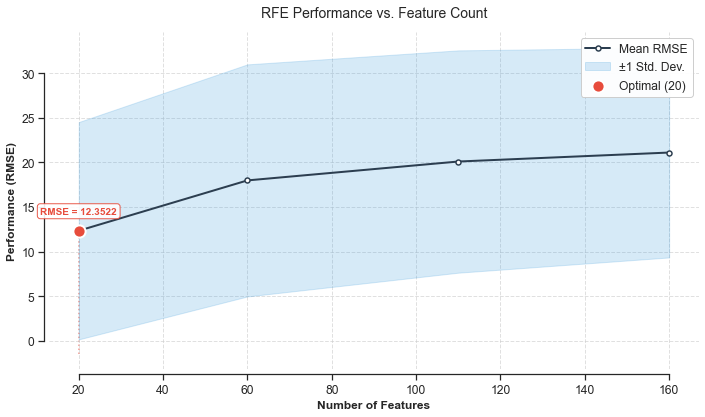

  Optimal Feature Set: 20 features
  Best RMSE: 12.3522


In [7]:
df_H_X_scaled, df_H_X_variance, RFE_results_H_1, df_H_X_RFE, RFE_results_H_2, df_H_X_final = feature_engineering_workflow('H')

In [8]:
def combine_features(df_L_X_final, df_H_X_final):

    # Number of features in each set
    n_features_L = df_L_X_final.shape[1]
    n_features_H = df_H_X_final.shape[1]
    print(f"Number of features in L dataset: {n_features_L}")
    print(f"Number of features in H dataset: {n_features_H}")

    # Number of overlapping features
    overlapping_features = set(df_L_X_final.columns).intersection(set(df_H_X_final.columns))
    n_overlapping_features = len(overlapping_features)
    print(f"Number of overlapping features: {n_overlapping_features}")
    print(f"Overlapping features: {overlapping_features}")

    # Combine features
    combined_features = list(set(df_L_X_final.columns).union(set(df_H_X_final.columns)))
    print(f"Total number of combined features: {len(combined_features)}")

    return combined_features

In [9]:
selected_features = combine_features(df_L_X_final, df_H_X_final)

Number of features in L dataset: 60
Number of features in H dataset: 20
Number of overlapping features: 0
Overlapping features: set()
Total number of combined features: 80


# Example showing how to get a dataset with the selected features

In [10]:
df_to_test_the_code = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').tail(500)

In [11]:
df = hf.dataset_featurization(df_to_test_the_code, selected_features, data_prefix + 'to_test_the_code')
df

✓ RDKit: Added 208 features
✓ MACCS: Added 167 features
Generating 70125 interaction features from 375 original features...
../data_curation/processed_data/to_test_the_code dataset saved.


,SMILES,MP,Type,RDKit_SMR_VSA10 X MACCS_127,RDKit_MaxEStateIndex,RDKit_SlogP_VSA2,RDKit_EState_VSA2 X RDKit_FractionCSP3,RDKit_PEOE_VSA9 X RDKit_SlogP_VSA4,RDKit_BertzCT X MACCS_145,RDKit_TPSA X RDKit_MolMR,...,RDKit_MaxEStateIndex X RDKit_BCUT2D_MWHI,RDKit_MinEStateIndex X RDKit_BCUT2D_MWHI,RDKit_BertzCT,RDKit_MaxEStateIndex X RDKit_FractionCSP3,RDKit_MolMR X MACCS_119,RDKit_MinEStateIndex X RDKit_BCUT2D_MRHI,MACCS_104 X MACCS_145,RDKit_NHOHCount X RDKit_MolMR,RDKit_SlogP_VSA1 X MACCS_104,RDKit_SMR_VSA10 X RDKit_MolMR
17133,O=c1oc2ccccc2c(c1C(c1c(=O)oc2c(c1O)cccc2)C)O,178.0,train_without_data_augmentation,21.938489,12.414025,10.213055,3.379197,0.000000,1165.758195,9665.776848,...,203.587187,-15.310824,1165.758195,1.241403,0.0000,-5.469605,0,191.6292,0.000000,2102.027521
17134,CC(=O)Nc1ccc(c(c1)C(F)(F)F)Br,118.0,train_without_data_augmentation,0.000000,12.423442,5.907180,2.257801,0.000000,0.000000,1555.328070,...,992.865681,-354.614602,389.434114,2.760765,0.0000,-40.392748,0,53.4477,0.000000,1471.121748
17135,NC(=O)c1ccccc1O,140.0,train_without_data_augmentation,5.907180,10.483981,11.013707,0.000000,0.000000,0.000000,2319.076004,...,170.433287,-9.963153,257.537949,0.000000,0.0000,-3.645676,0,109.8741,0.000000,216.348685
17136,COc1cc(N)c(cc1C(=O)NC1CCN(CC1)Cc1ccccc1)Cl,194.0,train_without_data_augmentation,23.195506,12.624512,37.048241,4.182157,0.000000,759.151653,7071.509124,...,448.115790,-6.236088,759.151653,4.418579,0.0000,-1.112355,1,313.8708,15.787319,2426.797330
17137,O=C([C@@H]1CC=CC[C@@H]1C(=O)O)OC(=O)[C@H]1CC=C...,100.0,train_without_data_augmentation,0.000000,12.136833,34.090276,12.841643,560.345792,524.977825,9092.962442,...,201.231667,-18.533625,524.977825,6.068416,0.0000,-6.617294,0,154.1572,0.000000,1840.422778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17628,[O-][N+](=O)CCO,-80.0,train_without_data_augmentation,0.000000,9.244861,23.181477,13.151638,0.000000,0.000000,1200.684064,...,153.730135,-9.469128,52.754888,9.244861,18.9472,-2.369118,0,18.9472,0.000000,0.000000
17629,N#CCc1ccc(cc1)OC(=O)C,50.0,train_without_data_augmentation,5.969305,10.549225,5.969305,1.193861,141.526086,0.000000,2357.636120,...,174.427544,-5.618204,334.937533,2.109845,0.0000,-1.932432,0,0.0000,0.000000,280.963261
17630,CCOC(=O)/C(=N\Nc1ccc(cc1)[N+](=O)[O-])/C(=O)C(...,184.0,train_without_data_augmentation,0.000000,12.426538,35.170727,4.495414,174.144077,0.000000,7968.065190,...,241.240240,-102.945453,640.336510,3.106634,71.8491,-35.269200,0,71.8491,0.000000,2072.056754
17631,O/N=C/1\C(=O)N(N=C1c1ccc(cc1)[N+](=O)[O-])c1cc...,223.0,train_without_data_augmentation,28.705322,12.308221,27.461114,0.000000,107.319970,828.315198,8973.666360,...,204.664527,-9.591241,828.315198,0.000000,82.7829,-3.887102,0,82.7829,0.000000,2376.309824
